# Question 01:

Draw a Neural Network

Draw a neural network with:

3 input features

3 hidden layers (at least 2 neurons each)

1 output neuron

a) Label all weights and biases. <br>
b) Write the forward equations layer by layer. <br>
c) If output uses Sigmoid, write the final prediction equation. <br>

Please note : Don't forget to attach a screen short of your neural network.

**Write** Answer 01:

a)


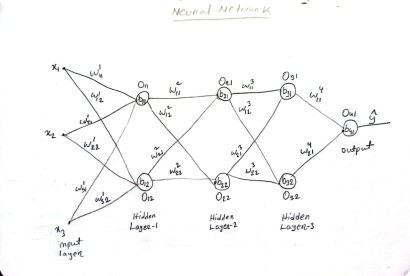

b, c)



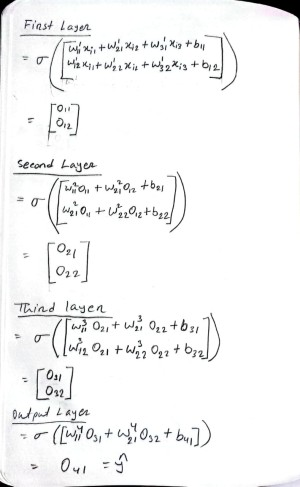

# Question 02:

Manual Gradient Calculation

Given:

z = w*x + b <br>
y_pred = sigmoid(z) <br>
L = −[ y log(y_pred) + (1−y) log(1−y_pred) ] <br>

a) Write dL/dy_pred <br>
b) Write dy_pred/dz <br>
c) Show that dL/dz = y_pred − y <br>

## Write Answer 02:

a)  

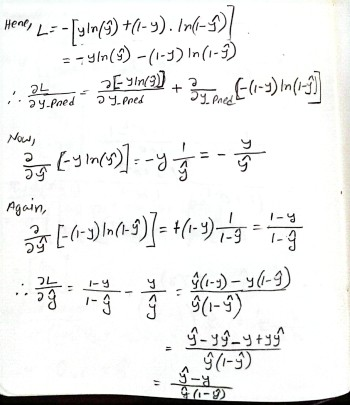

b)


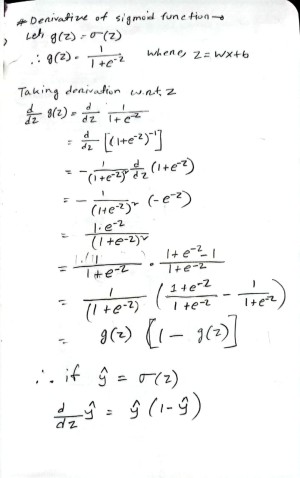

c)


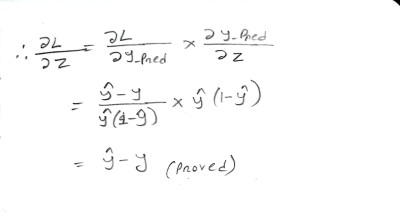

# Question 03:

x = 3
y1 = x^2
y2 = 4*x
L = y1 + y2

a) Draw the computation graph. <br>
b) Compute dL/dx manually. <br>
c) Explain how would you do it using Autograd <br>

## Write Answer 03:

a)

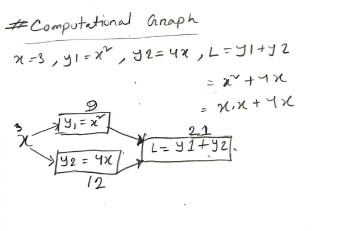

b)

In [3]:
def dL_dx(x):
  return 2*x+4

x = 3
print(dL_dx(x))

10


c)

Do do the derivation using autograd, at first I have to declare the x value which is 3, using pythorch method. And in the declaration the "required_grad" have to be True to track all the operation of variable x. And the equation L also have to be declared to do the farther operation. After that to do the derivaive of L w.r.t x, we have to call the function "backward()". Then we can get the result by x.grad.

# Question 04:

Create a scalar tensor x = 3.0 with gradient tracking enabled. <br>
Compute y = x² + 4x. <br>
Perform backpropagation. <br>
Print the gradient of x. <br>

Write the full PyTorch code yourself. <br>

## Write Answer 04:

In [6]:
import torch
x = torch.tensor(3.0, requires_grad=True)
y = (x**2) + (4*x)
y.backward()
x.grad

tensor(10.)

# Question 05:

Create two tensors:
w = 2.0 (requires_grad=True) <br>
b = 1.0 (requires_grad=True) <br>

Let input x = 3.0. <br>
Compute z = w*x + b. <br>
Use Sigmoid to get y_pred.
 <br>

Define Binary Cross Entropy manually (without built-in loss). <br>
Compute gradients using backward(). <br>
Print gradients of w and b. <br>

Write full code.

## Write Answer 05:

In [9]:
def binary_cross_entropy_loss(prediction, target):
  epsilon = 1e-8
  prediction = torch.clamp(prediction, epsilon, 1-epsilon)
  loss = -(target*torch.log(prediction) + (1-target)*torch.log(1-prediction))

  return loss

In [19]:
x = torch.tensor(3.0)
w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)
y = 0.0

z = w*x + b
z

tensor(7., grad_fn=<AddBackward0>)

In [20]:
y_pred = torch.sigmoid(z)
y_pred

tensor(0.9991, grad_fn=<SigmoidBackward0>)

In [21]:
loss = binary_cross_entropy_loss(y_pred, y)
loss.backward()
print(f"Gradient of w: {w.grad}")
print(f"Gradient of b: {b.grad}")

Gradient of w: 2.997267007827759
Gradient of b: 0.9990890026092529


# Question 06:

Create a tensor x = 2.0 (requires_grad=True). <br>
Compute:

y1 = x² <br>
y2 = 3x <br>
L = y1 + y2 <br>

Call backward(). <br>
Print x.grad. <br>

Write full PyTorch code.

## Write Answer 06:

In [22]:
x = torch.tensor(2.0, requires_grad=True)
y1 = x**2
y2 = 3*x
L = y1 + y2
L.backward()

x.grad

tensor(7.)

# Question 07:


Create tensor w = 2.0 (requires_grad=True). <br>

Compute two different losses sequentially and call backward() twice. <br>
Print w.grad. <br>

Do not clear gradients. <br>
Explain what you observe. <br>

Write full code.


## Write Answer 07:



In [24]:
w = torch.tensor(2.0, requires_grad=True)
# loss 1
L1 = 2*w
L1.backward()
print(f"First backward: {w.grad}")

# loss 2
L2 = 3*w
L2.backward()
print(f"Second bakcward: {w.grad}")

First backward: 2.0
Second bakcward: 5.0


In the followng code I have observed that the w.grad is not overwriting on the previous value. It accumulates gradients by default. Which is a problem because for the second loss the gradient should be 3. But it is giving accumulated result 5. So to avoid this problem we have to clear the gradient after using it.